# **Libraries**

In [9]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import numpy as np
import pandas as pd
import cv2
import datetime
import matplotlib.pyplot as plt
from PIL import Image
import re
import gc
import glob
import random
import seaborn as sns
import tensorflow as tf

from keras.models import Sequential, Model, load_model
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout, Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications import (
    EfficientNetV2S,
    ConvNeXtTiny,
)

2026-05-18 09:40:06.178601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
# from google.colab import drive
# drive.mount('/content/drive')

# **One time execution**

In [ ]:
#pip install split-folders

In [ ]:
#import splitfolders

In [ ]:
'''
def split():
    data_dir = os.path.join('/content/drive/MyDrive/binary_data/data')
    print("No of images in each class of data directory")
    for dir, subdir, files in os.walk(data_dir):
        print(dir,':', str(len(files)))
        
    splitfolders.ratio("/content/drive/MyDrive/binary_data/data", 
                       output = "/content/drive/MyDrive/binary_data_folders",
                       seed = 6, 
                       ratio = (0.8, 0.2), 
                       group_prefix = None, 
                       move = False)

if os.path.exists("/content/drive/MyDrive/binary_data_folders"):
    print("Files already present in splitted ratio 0.8, 0.2")
else:
    split()
    print("Files are splitted in the ratio 0.8, 0.2")
'''

In [ ]:
'''
classes_dict = {0: 'no', 1: 'yes'}
def grey():
    for i in classes_dict.values():
        directory = "binary_data\\" + i
        for filename in os.listdir(directory):
            f = os.path.join(directory, filename)
            img = Image.open(f).convert("L")
            img = img.save(f)
grey()
'''

# **Utility function**

In [11]:
PROJECT_ROOT = "/mnt/c/Users/test/OneDrive - Braude College of Engineering/Software Engineering Stuff/Capstone/Bug-bite-classification-using-a-TC-classification-model"

train = f'{PROJECT_ROOT}/Bug-Data/Binary_Bug_Data/train'
val   = f'{PROJECT_ROOT}/Bug-Data/Binary_Bug_Data/val'

In [12]:
def show_few_images(number_of_examples = 2, predict_using_model = None):
    figure1, ax1 = plt.subplots(number_of_examples,len(os.listdir(train)), figsize=(8, 4*number_of_examples))
    ax1 = ax1.reshape(-1)
    axoff_fun = np.vectorize(lambda ax:ax.axis('off'))
    axoff_fun(ax1)
    axs = 0
    for i, folder in enumerate(os.listdir(train)):
        image_ids = os.listdir(os.path.join(train,folder))
        for j in [random.randrange(0, len(image_ids)) for i in range(0,number_of_examples)]:
            display = plt.imread(os.path.join(train,folder,image_ids[j]))
            plt.axis('off')
            ax1[axs].imshow(display)
            title = 'True:'+folder
            if(predict_using_model):
                predicted_classname = inv_map_classes[np.argmax(inception_best_model.predict(np.array([display])))]
                title = title + '\nPredict :' + predicted_classname
            ax1[axs].set_title(title)
            axs=axs+1

In [13]:
def bar_plot(dir):
    x = len(os.listdir(dir + '/bites'))
    y = len(os.listdir(dir + '/no_bites'))
    category = ['bites', 'no_bites']
    count = [x, y]
    plot = plt.bar(category, count)
    plot[0].set_color('orange')
    plt.title('Number of images per class')
    plt.show()

In [14]:
def plot_performance_metrics(model):
    tr_loss = model.history['loss']
    val_loss = model.history['val_loss']

    tr_accuracy = model.history['accuracy']
    val_accuracy = model.history['val_accuracy']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
    plt.subplots_adjust(wspace=0.40)
    
    # Loss Plot
    ax1.plot(tr_loss)
    ax1.plot(val_loss)
    ax1.grid()
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend(['Train Loss', 'Test Loss'], loc='upper left')
    ax1.set_title('Plot of Train and Test Loss against Epochs')

    # Accuracy Plot
    ax2.plot(tr_accuracy)
    ax2.plot(val_accuracy)
    ax2.grid()
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend(['Train Accuracy', 'Test Accuracy'], loc = 'upper left')
    ax2.set_title('Plot of Train and Test Accuracy against Epoch')
  
    plt.show()

In [15]:
def predict_classes(predictions):
    valResult = predictions.copy()
    valResult[valResult <= 0.5] = 0  
    valResult[valResult > 0.5] = 1   
    return valResult

In [16]:
def plot_confusion_matrix(predictions, labels):
    valResult = predict_classes(predictions)    
    conf_matrix_df= pd.DataFrame(confusion_matrix(labels,valResult),
                                 index=["No", "Yes"],
                                 columns=["No", "Yes"])
    plt.figure(figsize=(7,6))
    plt.title("Confusion Matrix")    
    sns.heatmap(conf_matrix_df, annot = True, annot_kws = {"size" : "20"}, fmt = '.4g')    
    plt.xlabel('\nPredicted', fontsize = 12)    
    plt.ylabel('Actual', fontsize=12, rotation='horizontal', labelpad=40)

    # Get TP, FP, TN and FN
    cm = confusion_matrix(labels, valResult) 
    print('='*50)                                
    print('True Positive  (TP) = ', cm[0][0])
    print('False Positive (FP) = ', cm[0][1])
    print('False Negative (FN) = ', cm[1][0])
    print('True Negative  (TN) = ', cm[1][1])
    print('-'*26)
    
    # Get Precision, Recall and F1 Score.
    if (cm[0][0] + cm[0][1])!=0 and (cm[0][0], cm[1][0])!=0:
        precision= round((cm[0][0] / (cm[0][0] + cm[0][1]))*100, 2) 
        recall   = round((cm[0][0] / (cm[0][0] + cm[1][0]))*100, 2) 
        f1_score = round(2*((precision*recall)/(precision+recall)), 2) 
              
        print(f'Precision Score: {precision}%')
        print(f'Recall Score: {recall}%')
        print(f'F1 Score: {f1_score}%')
        print('='*50) 
        print('\n')

In [17]:
def plot_roc_curve(predictions, labels):
    fpr, tpr, thresholds = roc_curve(labels, predictions)
    auc = roc_auc_score(labels, predictions)
    plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.plot(fpr, tpr, "g", label="AUC Score = %0.2f" % auc)
    plt.plot([0, 1], [0, 1], "r--")
    plt.ylabel("True Positive Rate (TPR)", fontsize=12)
    plt.xlabel("False Positive Rate (FPR)", fontsize=12)
    plt.legend()
    plt.grid()
    plt.show()

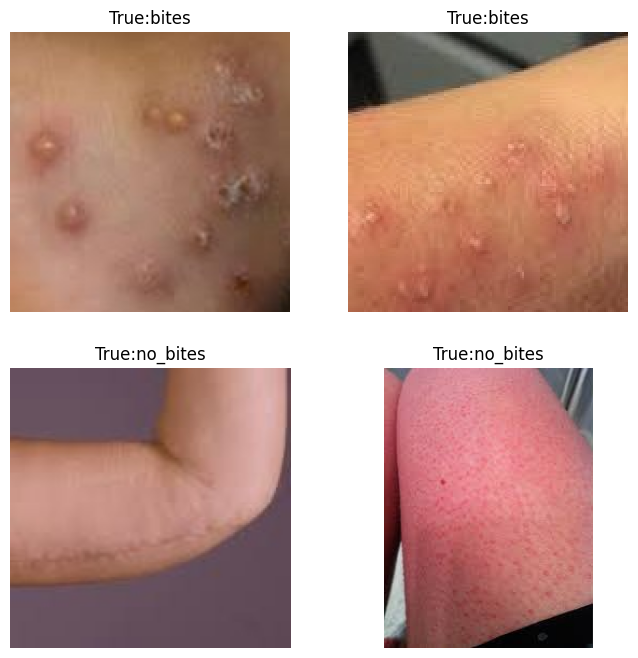

In [18]:
show_few_images(2)

Training images

bites:    267
no_bites: 127
Total:    394
*************************************************


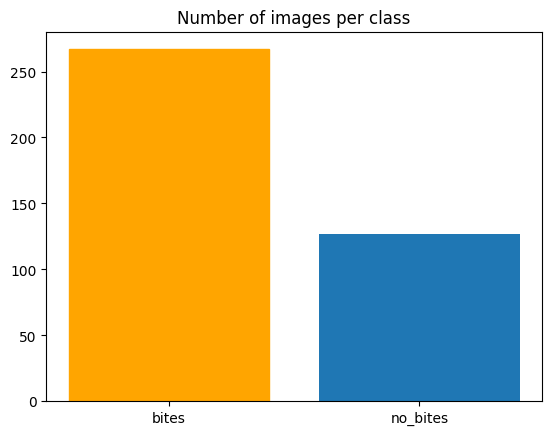


Validation images

bites:    31
no_bites: 31
Total:    62
*************************************************


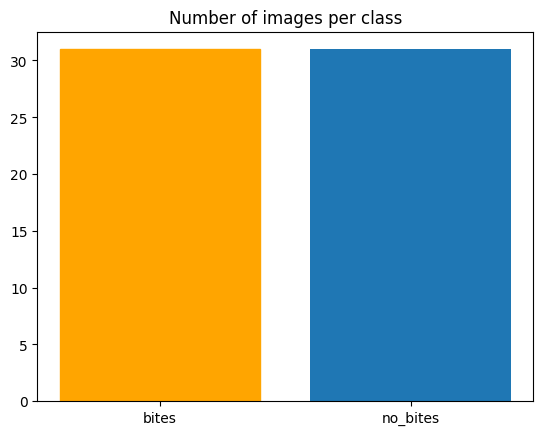

In [19]:
print('Training images\n')
print('bites:   ', len(os.listdir(train + '/bites')))
print('no_bites:', len(os.listdir(train + '/no_bites')))
print('Total:   ', len(os.listdir(train + '/bites')) + len(os.listdir(train + '/no_bites')))
print('*' * 49)
bar_plot(train)
print('\nValidation images\n')
print('bites:   ', len(os.listdir(val + '/bites')))
print('no_bites:', len(os.listdir(val + '/no_bites')))
print('Total:   ', len(os.listdir(val + '/bites')) + len(os.listdir(val + '/no_bites')))
print('*' * 49)
bar_plot(val)

# **Data Preparation**

In [20]:
width, height = 310, 310
train_batch_size = 32
val_batch_size   = 16

Data generator for train set included augmentation and processing (shear, zoom, horizontal_flip, rescale). For the test set only rescale should be made (we don't want to mess with new data - just predict its class).

In [21]:
trainDataGen = ImageDataGenerator(rescale = 1./255, rotation_range = 10, width_shift_range = 0.1)
validationDataGen = ImageDataGenerator(rescale = 1./255.)

It is important to put "shuffle" equal to False in test generator. Otherwise order of test pictures will be distorted by the function and predictions won't fit order expected by Kaggle checking system.

For test data batch size is 1 as we apply trained model to all test pictures without separating them by batches.

In [22]:
train_generator = trainDataGen.flow_from_directory(train, target_size = (height, width), batch_size = train_batch_size, class_mode = 'binary', shuffle = True)
validation_generator = validationDataGen.flow_from_directory(val, target_size = (height, width), batch_size = val_batch_size, class_mode = 'binary', shuffle = False)

Found 393 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


# **EfficientNetV2S**

In [23]:
tf.keras.backend.clear_session()

In [24]:
# include_preprocessing=False because our generator already rescales to [0,1]
eff_base = EfficientNetV2S(
    weights='imagenet', include_top=False,
    input_shape=(height, width, 3), pooling='avg',
    include_preprocessing=False
)
for layer in eff_base.layers:
    layer.trainable = False

x = Dense(256, activation='relu')(eff_base.output)
x = Dropout(0.3)(x)
x = Dense(1, activation='sigmoid')(x)
efficientnetv2s_model = Model(eff_base.input, x)

2026-05-18 09:40:11.014866: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1779086411.014918   34124 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20232 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [25]:
efficientnetv2s_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
training_steps   = train_generator.samples // train_batch_size
validation_steps = validation_generator.samples // val_batch_size

In [27]:
eff_save_path = f'{PROJECT_ROOT}/Model_Weights/binary_efficientnetv2s.keras'
eff_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(eff_save_path, monitor='val_accuracy', save_best_only=True, verbose=0),
]

eff_history = efficientnetv2s_model.fit(
    train_generator,
    steps_per_epoch=training_steps,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=eff_callbacks
)

Epoch 1/30


2026-05-18 09:40:32.062936: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d39b0002fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-18 09:40:32.062968: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2026-05-18 09:40:32.603300: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-18 09:40:37.002542: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-05-18 09:40:40.081750: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-18 09:40:40.846200: I external

 2/12 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5781 - loss: 0.6844 

2026-05-18 09:41:10.356681: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng53{k2=3,k13=0,k14=1,k18=0,k23=0} for conv (f32[9,48,78,78]{3,2,1,0}, u8[0]{0}) custom-call(f32[9,192,78,78]{3,2,1,0}, f32[48,192,1,1]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-05-18 09:41:10.359648: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.374376728s
Trying algorithm eng53{k2=3,k13=0,k14=1,k18=0,k23=0} for conv (f32[9,48,78,78]{3,2,1,0}, u8[0]{0}) custom-call(f32[9,192,78,78]{3,2,1,0}, f32[48,192,1,1]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config=

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6102 - loss: 0.6629

2026-05-18 09:41:40.370634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:41:40.561317: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:41:40.759764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:41:40.963849: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:41:41.056304: E external/local_xla/xla/service

12/12 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.6482 - loss: 0.6318 - val_accuracy: 0.6250 - val_loss: 0.5813 - learning_rate: 1.0000e-04
Epoch 2/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.5938 - loss: 0.6553

/home/test/tc-env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5938 - loss: 0.6553 - val_accuracy: 0.6250 - val_loss: 0.5768 - learning_rate: 1.0000e-04
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 622ms/step - accuracy: 0.7285 - loss: 0.5262 - val_accuracy: 0.6667 - val_loss: 0.5255 - learning_rate: 1.0000e-04
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.6250 - loss: 0.5387 - val_accuracy: 0.7083 - val_loss: 0.5204 - learning_rate: 1.0000e-04
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 605ms/step - accuracy: 0.7756 - loss: 0.4621 - val_accuracy: 0.7917 - val_loss: 0.4655 - learning_rate: 1.0000e-04
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.9062 - loss: 0.3319 - val_accuracy: 0.8125 - val_loss: 0.4615 - learning_rate: 1.0000e-04
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 789ms/step - accuracy: 0.8393 - loss: 0.3985 - val_accuracy: 0.8333 - val_loss: 0.4218 - learning_rate: 1.0000e-04
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8125 - loss

In [28]:
efficientnetv2s_model.save(eff_save_path)
print(f'Saved: {eff_save_path}')

Saved: /mnt/c/Users/test/OneDrive - Braude College of Engineering/Software Engineering Stuff/Capstone/Bug-bite-classification-using-a-TC-classification-model/Model_Weights/binary_efficientnetv2s.keras


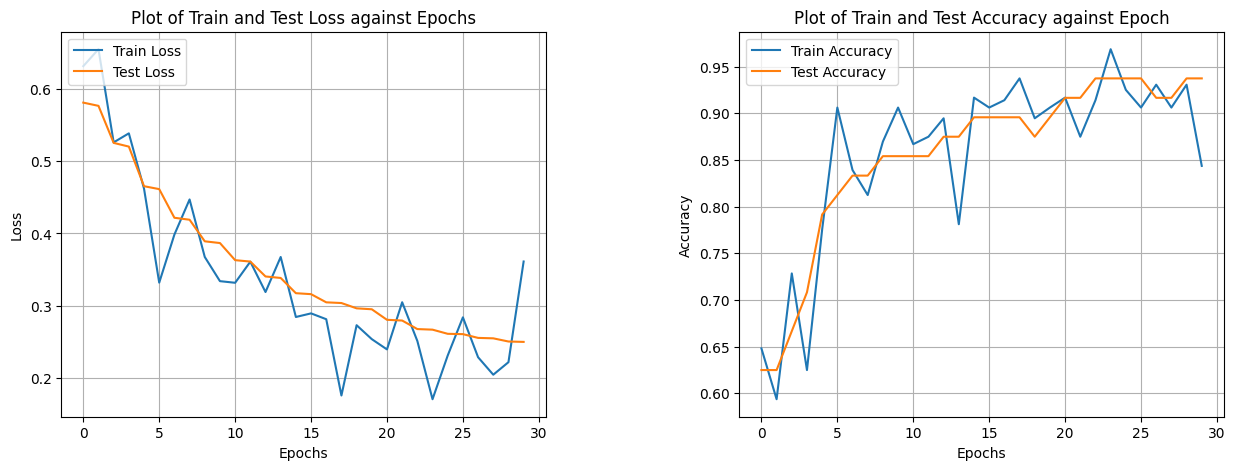

In [29]:
plot_performance_metrics(eff_history)

In [30]:
validation_generator.reset()
eff_prediction = efficientnetv2s_model.predict(validation_generator, verbose=1)
actual_class = validation_generator.classes

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

2026-05-18 09:44:05.668290: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:44:05.864749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:44:06.486353: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:44:06.718551: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:44:06.914610: E external/local_xla/xla/stream_

4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step


True Positive  (TP) =  30
False Positive (FP) =  1
False Negative (FN) =  6
True Negative  (TN) =  25
--------------------------
Precision Score: 96.77%
Recall Score: 83.33%
F1 Score: 89.55%




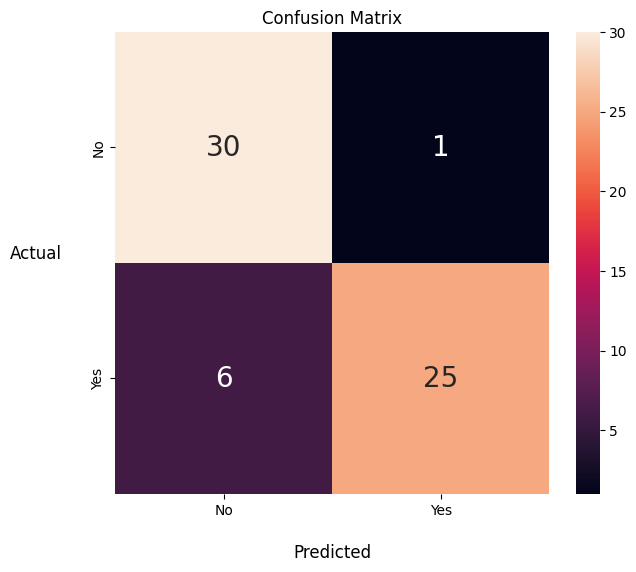

In [31]:
plot_confusion_matrix(eff_prediction, actual_class)

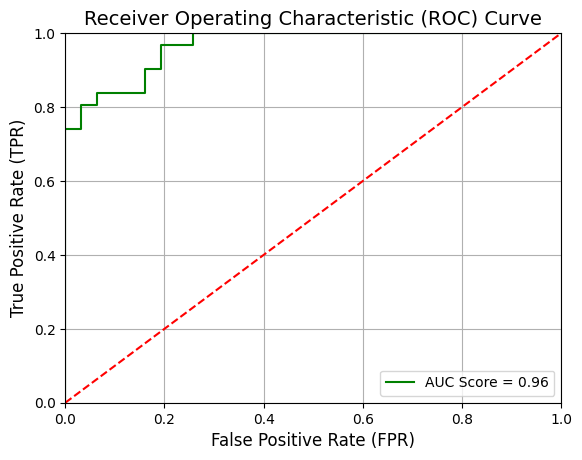


 Classification Report:

              precision    recall  f1-score   support

       bites       0.83      0.97      0.90        31
    no_bites       0.96      0.81      0.88        31

    accuracy                           0.89        62
   macro avg       0.90      0.89      0.89        62
weighted avg       0.90      0.89      0.89        62



In [32]:
plot_roc_curve(eff_prediction, actual_class)
print('=' * 55)
print('\n Classification Report:\n')
print(classification_report(actual_class, predict_classes(eff_prediction), target_names=['bites', 'no_bites']))
print('=' * 55)

# **ConvNeXtTiny**

In [33]:
tf.keras.backend.clear_session()

In [34]:
# include_preprocessing=False because our generator already rescales to [0,1]
cnx_base = ConvNeXtTiny(
    weights='imagenet', include_top=False,
    input_shape=(height, width, 3), pooling='avg',
    include_preprocessing=False
)
for layer in cnx_base.layers:
    layer.trainable = False

x = Dense(256, activation='relu')(cnx_base.output)
x = Dropout(0.3)(x)
x = Dense(1, activation='sigmoid')(x)
convnext_tiny_model = Model(cnx_base.input, x)
convnext_tiny_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 310, 310,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stem  │ (None, 77, 77,    │      4,896 │ input_layer[0][0] │
│ (Sequential)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │      4,800 │ convnext_tiny_st… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │         96 │ convnext_tiny_st… │
│ (LayerScale)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 77, 77,    │          0 │ convnext_tiny_st… │
│                     │ 96)               │            │ convnext_tiny_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │      4,800 │ add[0][0]         │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │         96 │ convnext_tiny_st… │
│ (LayerScale)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 77, 77,    │          0 │ convnext_tiny_st

 Total params: 28,017,249 (106.88 MB)

 Trainable params: 197,121 (770.00 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

In [35]:
convnext_tiny_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [36]:
training_steps   = train_generator.samples // train_batch_size
validation_steps = validation_generator.samples // val_batch_size

In [37]:
cnx_save_path = f'{PROJECT_ROOT}/Model_Weights/binary_convnext_tiny.keras'
cnx_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(cnx_save_path, monitor='val_accuracy', save_best_only=True, verbose=0),
]

cnx_history = convnext_tiny_model.fit(
    train_generator,
    steps_per_epoch=training_steps,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=cnx_callbacks
)

Epoch 1/30


2026-05-18 09:44:20.635574: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-18 09:44:21.074210: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 8 bytes spill loads

2026-05-18 09:44:21.321654: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 60 bytes spill stores, 60 bytes spill loads

2026-05-18 09:44:21.766131: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30', 360 bytes spill

 5/12 ━━━━━━━━━━━━━━━━━━━━ 5s 751ms/step - accuracy: 0.5676 - loss: 0.7505

2026-05-18 09:44:34.988675: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 8 bytes spill loads

2026-05-18 09:44:35.270914: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_31', 64 bytes spill stores, 64 bytes spill loads

2026-05-18 09:44:35.324127: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 60 bytes spill stores, 60 bytes spill loads

2026-05-18 09:44:35.760170: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_31', 4 bytes spill stores, 4 bytes spill loads

2026-05-18 09:44:35.836168: I external/local_xla/xla/s

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5963 - loss: 0.7167

2026-05-18 09:44:46.715958: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 8 bytes spill loads

2026-05-18 09:44:47.331368: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 64 bytes spill stores, 64 bytes spill loads

2026-05-18 09:44:47.440444: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 60 bytes spill stores, 60 bytes spill loads

2026-05-18 09:44:47.645598: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 16 bytes spill stores, 16 bytes spill loads

2026-05-18 09:44:47.770396: I external/local_xla/xla/

12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6482 - loss: 0.6569 - val_accuracy: 0.6875 - val_loss: 0.5882 - learning_rate: 1.0000e-04
Epoch 2/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7188 - loss: 0.5183

/home/test/tc-env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7188 - loss: 0.5183 - val_accuracy: 0.6875 - val_loss: 0.5835 - learning_rate: 1.0000e-04
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 555ms/step - accuracy: 0.7175 - loss: 0.5418 - val_accuracy: 0.7917 - val_loss: 0.5091 - learning_rate: 1.0000e-04
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7500 - loss: 0.4491 - val_accuracy: 0.7917 - val_loss: 0.5032 - learning_rate: 1.0000e-04
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 588ms/step - accuracy: 0.7673 - loss: 0.4717 - val_accuracy: 0.7708 - val_loss: 0.4575 - learning_rate: 1.0000e-04
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8125 - loss: 0.4683 - val_accuracy: 0.7708 - val_loss: 0.4542 - learning_rate: 1.0000e-04
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 554ms/step - accuracy: 0.8061 - loss: 0.4213 - val_accuracy: 0.8125 - val_loss: 0.4143 - learning_rate: 1.0000e-04
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9688 - loss: 

In [38]:
convnext_tiny_model.save(cnx_save_path)
print(f'Saved: {cnx_save_path}')

Saved: /mnt/c/Users/test/OneDrive - Braude College of Engineering/Software Engineering Stuff/Capstone/Bug-bite-classification-using-a-TC-classification-model/Model_Weights/binary_convnext_tiny.keras


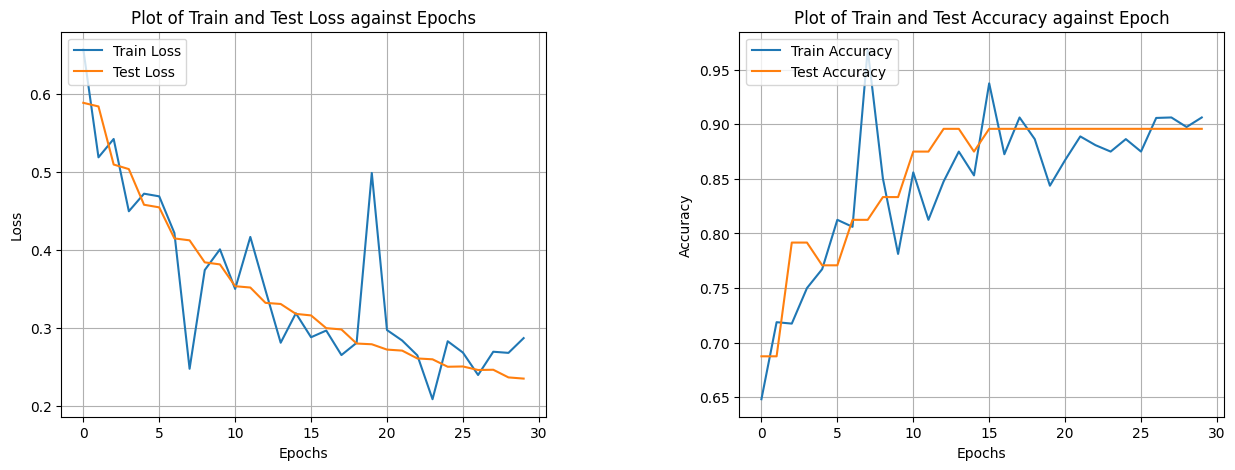

In [39]:
plot_performance_metrics(cnx_history)

In [40]:
validation_generator.reset()
cnx_prediction = convnext_tiny_model.predict(validation_generator, verbose=1)
actual_class = validation_generator.classes

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

2026-05-18 09:46:38.885267: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 16 bytes spill stores, 16 bytes spill loads

2026-05-18 09:46:39.137505: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 60 bytes spill stores, 60 bytes spill loads

2026-05-18 09:46:39.355900: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 64 bytes spill stores, 64 bytes spill loads

2026-05-18 09:46:39.361697: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 8 bytes spill loads

2026-05-18 09:46:39.552166: I external/local_xla/xla/s

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step


True Positive  (TP) =  28
False Positive (FP) =  3
False Negative (FN) =  3
True Negative  (TN) =  28
--------------------------
Precision Score: 90.32%
Recall Score: 90.32%
F1 Score: 90.32%




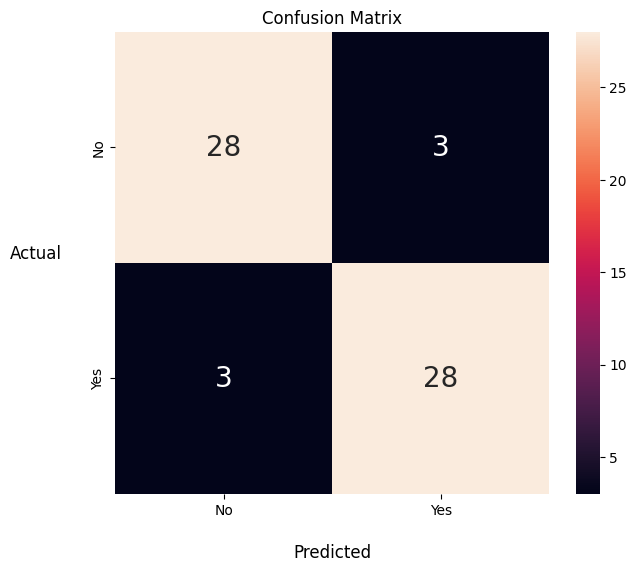

In [41]:
plot_confusion_matrix(cnx_prediction, actual_class)

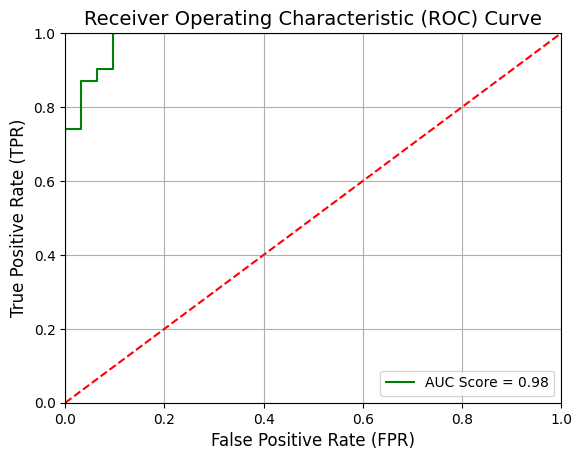


 Classification Report:

              precision    recall  f1-score   support

       bites       0.90      0.90      0.90        31
    no_bites       0.90      0.90      0.90        31

    accuracy                           0.90        62
   macro avg       0.90      0.90      0.90        62
weighted avg       0.90      0.90      0.90        62



In [42]:
plot_roc_curve(cnx_prediction, actual_class)
print('=' * 55)
print('\n Classification Report:\n')
print(classification_report(actual_class, predict_classes(cnx_prediction), target_names=['bites', 'no_bites']))
print('=' * 55)

# **EfficientNet-B0**

In [43]:
tf.keras.backend.clear_session()

# EfficientNetB0 expects raw [0, 255] — separate generator without rescaling
EFF_B0_SIZE = 224

eff_b0_train_datagen = ImageDataGenerator(rotation_range=15, zoom_range=0.10, fill_mode='reflect')
eff_b0_val_datagen   = ImageDataGenerator()

eff_b0_train_gen = eff_b0_train_datagen.flow_from_directory(
    train, target_size=(EFF_B0_SIZE, EFF_B0_SIZE),
    batch_size=train_batch_size, class_mode='binary', shuffle=True)
eff_b0_val_gen = eff_b0_val_datagen.flow_from_directory(
    val, target_size=(EFF_B0_SIZE, EFF_B0_SIZE),
    batch_size=val_batch_size, class_mode='binary', shuffle=False)

Found 393 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


In [44]:
from tensorflow.keras.applications import EfficientNetB0

eff_b0_base = EfficientNetB0(
    weights='imagenet', include_top=False,
    input_shape=(EFF_B0_SIZE, EFF_B0_SIZE, 3), pooling='avg'
)
for layer in eff_b0_base.layers:
    layer.trainable = False

x = Dense(256, activation='relu')(eff_b0_base.output)
x = Dropout(0.3)(x)
x = Dense(1, activation='sigmoid')(x)
eff_b0_model = Model(eff_b0_base.input, x)
eff_b0_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [45]:
from sklearn.utils.class_weight import compute_class_weight

_cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=eff_b0_train_gen.classes)
eff_b0_class_weight = dict(enumerate(_cw))
print('class weights:', eff_b0_class_weight)

eff_b0_model.compile(optimizer=Adam(learning_rate=1e-4),
                      loss='binary_crossentropy', metrics=['accuracy'])

eff_b0_steps_train = eff_b0_train_gen.samples // train_batch_size
eff_b0_steps_val   = eff_b0_val_gen.samples   // val_batch_size
eff_b0_save_path   = f'{PROJECT_ROOT}/Model_Weights/binary_efficientnetb0_best.keras'

eff_b0_cb = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(eff_b0_save_path, monitor='val_accuracy', save_best_only=True, verbose=0),
]

print('── Phase 1 — backbone frozen (lr=1e-4) ──')
eff_b0_history_p1 = eff_b0_model.fit(
    eff_b0_train_gen,
    steps_per_epoch=eff_b0_steps_train,
    epochs=30,
    validation_data=eff_b0_val_gen,
    validation_steps=eff_b0_steps_val,
    class_weight=eff_b0_class_weight,
    callbacks=eff_b0_cb
)

class weights: {0: np.float64(0.7359550561797753), 1: np.float64(1.5595238095238095)}
── Phase 1 — backbone frozen (lr=1e-4) ──
Epoch 1/30


2026-05-18 09:47:03.275018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:47:03.487604: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:47:03.700473: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:47:03.899610: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:47:04.063717: E external/local_xla/xla/service

 1/12 ━━━━━━━━━━━━━━━━━━━━ 4:09 23s/step - accuracy: 0.4062 - loss: 0.8859

2026-05-18 09:47:18.385308: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:47:19.819699: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[9,672,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[9,672,14,14]{3,2,1,0}, f32[672,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=672, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-05-18 09:47:19.890921: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optim

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5175 - loss: 0.7508

2026-05-18 09:47:37.240128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:47:37.452340: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:47:37.624394: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:47:38.652007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:47:38.925441: E external/local_xla/xla/stream_

12/12 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.5956 - loss: 0.6932 - val_accuracy: 0.7500 - val_loss: 0.6141 - learning_rate: 1.0000e-04
Epoch 2/30
 1/12 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.6562 - loss: 0.6427

/home/test/tc-env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6562 - loss: 0.6427 - val_accuracy: 0.7500 - val_loss: 0.6079 - learning_rate: 1.0000e-04
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 392ms/step - accuracy: 0.7368 - loss: 0.5995 - val_accuracy: 0.7917 - val_loss: 0.5529 - learning_rate: 1.0000e-04
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6875 - loss: 0.4936 - val_accuracy: 0.8125 - val_loss: 0.5489 - learning_rate: 1.0000e-04
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 497ms/step - accuracy: 0.7922 - loss: 0.5190 - val_accuracy: 0.8542 - val_loss: 0.4998 - learning_rate: 1.0000e-04
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8438 - loss: 0.4345 - val_accuracy: 0.8542 - val_loss: 0.4964 - learning_rate: 1.0000e-04
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step - accuracy: 0.8366 - loss: 0.4584 - val_accuracy: 0.8750 - val_loss: 0.4604 - learning_rate: 1.0000e-04
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8438 - loss: 

In [46]:
print('── Phase 2 — fine-tune top 20 backbone layers (lr=1e-5) ──')
eff_b0_base.trainable = True
for layer in eff_b0_base.layers[:-20]:
    layer.trainable = False

eff_b0_model.compile(optimizer=Adam(learning_rate=1e-5),
                      loss='binary_crossentropy', metrics=['accuracy'])

# Fresh callbacks — reusing Phase 1 instances carries over their internal best state
eff_b0_cb_p2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(eff_b0_save_path, monitor='val_accuracy', save_best_only=True, verbose=0),
]

eff_b0_history_p2 = eff_b0_model.fit(
    eff_b0_train_gen,
    steps_per_epoch=eff_b0_steps_train,
    epochs=20,
    validation_data=eff_b0_val_gen,
    validation_steps=eff_b0_steps_val,
    class_weight=eff_b0_class_weight,
    callbacks=eff_b0_cb_p2
)

eff_b0_model.save(eff_b0_save_path)
print(f'Saved: {eff_b0_save_path}')

── Phase 2 — fine-tune top 20 backbone layers (lr=1e-5) ──
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9335 - loss: 0.2313 - val_accuracy: 0.8958 - val_loss: 0.3069 - learning_rate: 1.0000e-05
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9062 - loss: 0.1864 - val_accuracy: 0.8958 - val_loss: 0.3066 - learning_rate: 1.0000e-05
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 340ms/step - accuracy: 0.9224 - loss: 0.2427 - val_accuracy: 0.8958 - val_loss: 0.3048 - learning_rate: 1.0000e-05
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8125 - loss: 0.3107 - val_accuracy: 0.8958 - val_loss: 0.3046 - learning_rate: 1.0000e-05
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 465ms/step - accuracy: 0.9086 - loss: 0.2471 - val_accuracy: 0.8958 - val_loss: 0.3029 - learning_rate: 1.0000e-05
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9062 - loss: 0.2045 - val_accuracy: 0.8958 - val_loss: 0.3028 - learning_rate: 1.0000e-05
Epoch 7/20

── Phase 1 ──


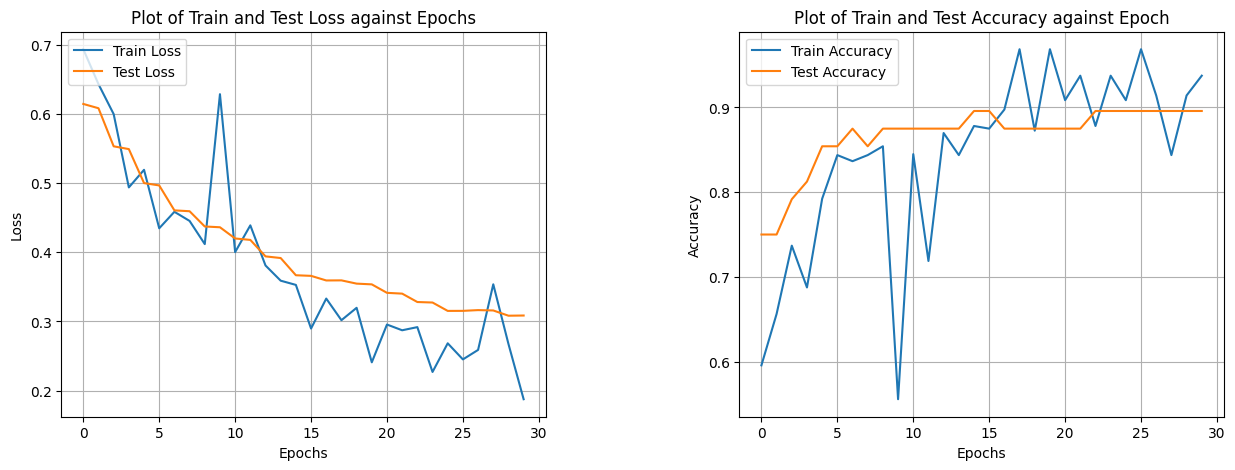

── Phase 2 ──


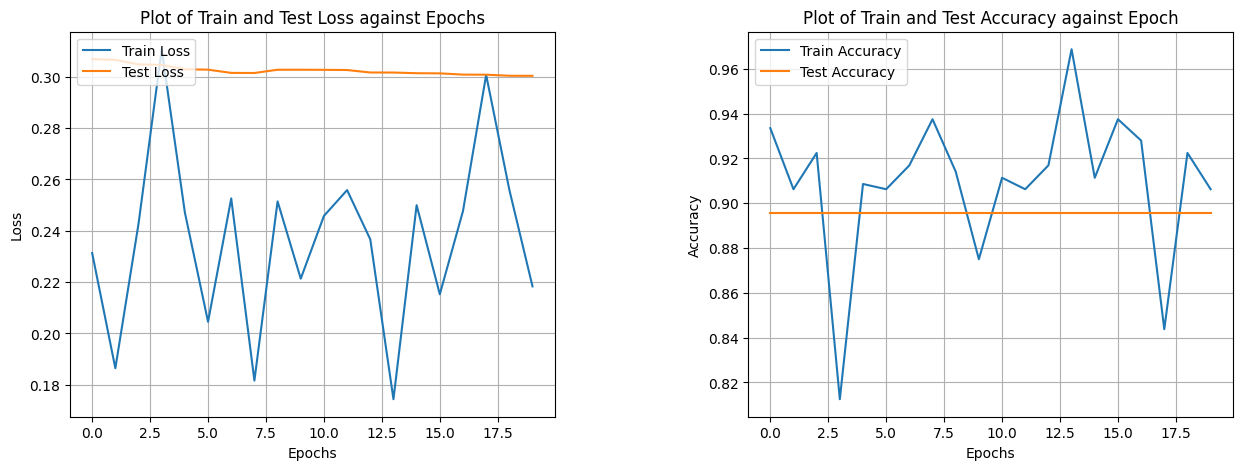

In [47]:
print('── Phase 1 ──')
plot_performance_metrics(eff_b0_history_p1)
print('── Phase 2 ──')
plot_performance_metrics(eff_b0_history_p2)

2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

2026-05-18 09:50:20.449964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:50:20.655660: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:50:20.869284: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:50:21.052211: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 09:50:21.209843: E external/local_xla/xla/service

4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step
True Positive  (TP) =  26
False Positive (FP) =  5
False Negative (FN) =  1
True Negative  (TN) =  30
--------------------------
Precision Score: 83.87%
Recall Score: 96.3%
F1 Score: 89.66%




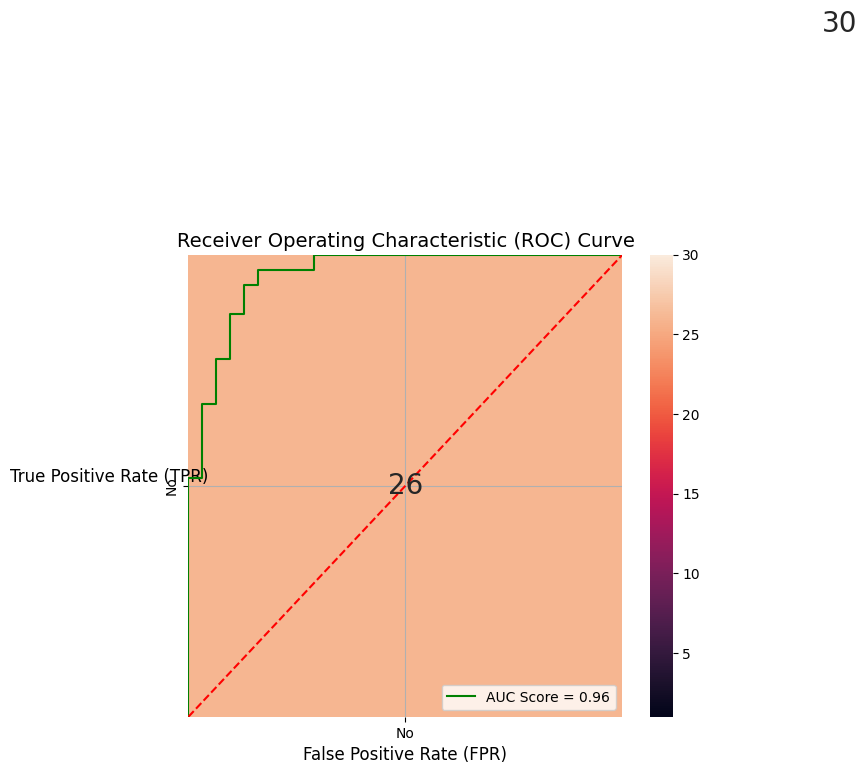


 Classification Report:

              precision    recall  f1-score   support

       bites       0.96      0.84      0.90        31
    no_bites       0.86      0.97      0.91        31

    accuracy                           0.90        62
   macro avg       0.91      0.90      0.90        62
weighted avg       0.91      0.90      0.90        62



In [48]:
eff_b0_val_gen.reset()
eff_b0_prediction = eff_b0_model.predict(eff_b0_val_gen, verbose=1)
actual_class_b0   = eff_b0_val_gen.classes

plot_confusion_matrix(eff_b0_prediction, actual_class_b0)
plot_roc_curve(eff_b0_prediction, actual_class_b0)
print('=' * 55)
print('\n Classification Report:\n')
print(classification_report(actual_class_b0, predict_classes(eff_b0_prediction),
                             target_names=['bites', 'no_bites']))
print('=' * 55)

# **DINOv2 ViT-S**

In [51]:
import torch
import timm
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

dino_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DINOv2 device:', dino_device)

# Disable Flash/CUTLASS attention — not universally supported across all CUDA builds
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

DINO_IMG_SIZE = 224
DINO_BATCH    = 16

dino_train_tf = transforms.Compose([
    transforms.Resize((DINO_IMG_SIZE, DINO_IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(DINO_IMG_SIZE, scale=(0.90, 1.10), ratio=(1.0, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
dino_val_tf = transforms.Compose([
    transforms.Resize((DINO_IMG_SIZE, DINO_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

dino_train_ds = datasets.ImageFolder(train, transform=dino_train_tf)
dino_val_ds   = datasets.ImageFolder(val,   transform=dino_val_tf)

_counts         = np.bincount(dino_train_ds.targets)
_sample_weights = [1.0 / _counts[t] for t in dino_train_ds.targets]
dino_sampler    = WeightedRandomSampler(_sample_weights, len(_sample_weights), replacement=True)

dino_train_loader = DataLoader(dino_train_ds, batch_size=DINO_BATCH, sampler=dino_sampler, num_workers=0)
dino_val_loader   = DataLoader(dino_val_ds,   batch_size=DINO_BATCH, shuffle=False,        num_workers=0)

print('Class mapping:', dino_train_ds.class_to_idx)
print(f'Train: {len(dino_train_ds)}  |  Val: {len(dino_val_ds)}')

def dino_eval(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.float().to(device)
            preds = (torch.sigmoid(model(X).view(-1)) >= 0.5).long()
            correct += (preds == y.long()).sum().item()
            total   += y.size(0)
    return correct / total

# img_size=224 overrides the default strict 518x518 input size
dino_model     = timm.create_model('vit_small_patch14_reg4_dinov2', pretrained=True, num_classes=1, img_size=224)
dino_criterion = nn.BCEWithLogitsLoss()
dino_best_acc  = 0.0
dino_save_path = f'{PROJECT_ROOT}/Model_Weights/binary_dinov2_vits_best.pt'

for name, param in dino_model.named_parameters():
    param.requires_grad = 'head' in name
dino_model = dino_model.to(dino_device)

print('\n── Phase 1 — head only (backbone frozen) ──')
opt1 = AdamW(filter(lambda p: p.requires_grad, dino_model.parameters()), lr=1e-3, weight_decay=1e-4)
sch1 = CosineAnnealingLR(opt1, T_max=30)
pat  = 0

for ep in range(30):
    dino_model.train()
    for X, y in dino_train_loader:
        X, y = X.to(dino_device), y.float().to(dino_device)
        opt1.zero_grad()
        dino_criterion(dino_model(X).view(-1), y).backward()
        opt1.step()
    sch1.step()
    vacc = dino_eval(dino_model, dino_val_loader, dino_device)
    if vacc > dino_best_acc:
        dino_best_acc = vacc
        torch.save(dino_model.state_dict(), dino_save_path)
        pat = 0
    else:
        pat += 1
    print(f'  Epoch {ep+1:02d} | val_acc={vacc:.4f} | best={dino_best_acc:.4f}')
    if pat >= 7:
        print('  Early stopping.'); break

DINOv2 device: cuda
Class mapping: {'bites': 0, 'no_bites': 1}
Train: 393  |  Val: 62

── Phase 1 — head only (backbone frozen) ──
  Epoch 01 | val_acc=0.8065 | best=0.8065
  Epoch 02 | val_acc=0.8710 | best=0.8710
  Epoch 03 | val_acc=0.8710 | best=0.8710
  Epoch 04 | val_acc=0.8387 | best=0.8710
  Epoch 05 | val_acc=0.9355 | best=0.9355
  Epoch 06 | val_acc=0.8871 | best=0.9355
  Epoch 07 | val_acc=0.9032 | best=0.9355
  Epoch 08 | val_acc=0.9194 | best=0.9355
  Epoch 09 | val_acc=0.9194 | best=0.9355
  Epoch 10 | val_acc=0.9194 | best=0.9355
  Epoch 11 | val_acc=0.9194 | best=0.9355
  Epoch 12 | val_acc=0.9032 | best=0.9355
  Early stopping.


In [52]:
print('── Phase 2 — full fine-tune (lr=1e-5) ──')
for param in dino_model.parameters():
    param.requires_grad = True

opt2 = AdamW(dino_model.parameters(), lr=1e-5, weight_decay=1e-4)
sch2 = CosineAnnealingLR(opt2, T_max=20)
pat  = 0

for ep in range(20):
    dino_model.train()
    for X, y in dino_train_loader:
        X, y = X.to(dino_device), y.float().to(dino_device)
        opt2.zero_grad()
        dino_criterion(dino_model(X).view(-1), y).backward()
        opt2.step()
    sch2.step()
    vacc = dino_eval(dino_model, dino_val_loader, dino_device)
    if vacc > dino_best_acc:
        dino_best_acc = vacc
        torch.save(dino_model.state_dict(), dino_save_path)
        pat = 0
    else:
        pat += 1
    print(f'  Epoch {ep+1:02d} | val_acc={vacc:.4f} | best={dino_best_acc:.4f}')
    if pat >= 7:
        print('  Early stopping.'); break

print(f'\nBest val acc: {dino_best_acc:.4f} — saved to {dino_save_path}')

── Phase 2 — full fine-tune (lr=1e-5) ──
  Epoch 01 | val_acc=0.8871 | best=0.9355
  Epoch 02 | val_acc=0.9677 | best=0.9677
  Epoch 03 | val_acc=0.9516 | best=0.9677
  Epoch 04 | val_acc=0.9839 | best=0.9839
  Epoch 05 | val_acc=0.9516 | best=0.9839
  Epoch 06 | val_acc=0.9677 | best=0.9839
  Epoch 07 | val_acc=0.9839 | best=0.9839
  Epoch 08 | val_acc=0.9839 | best=0.9839
  Epoch 09 | val_acc=0.9839 | best=0.9839
  Epoch 10 | val_acc=0.9839 | best=0.9839
  Epoch 11 | val_acc=0.9839 | best=0.9839
  Early stopping.

Best val acc: 0.9839 — saved to /mnt/c/Users/test/OneDrive - Braude College of Engineering/Software Engineering Stuff/Capstone/Bug-bite-classification-using-a-TC-classification-model/Model_Weights/binary_dinov2_vits_best.pt


True Positive  (TP) =  30
False Positive (FP) =  1
False Negative (FN) =  0
True Negative  (TN) =  31
--------------------------
Precision Score: 96.77%
Recall Score: 100.0%
F1 Score: 98.36%




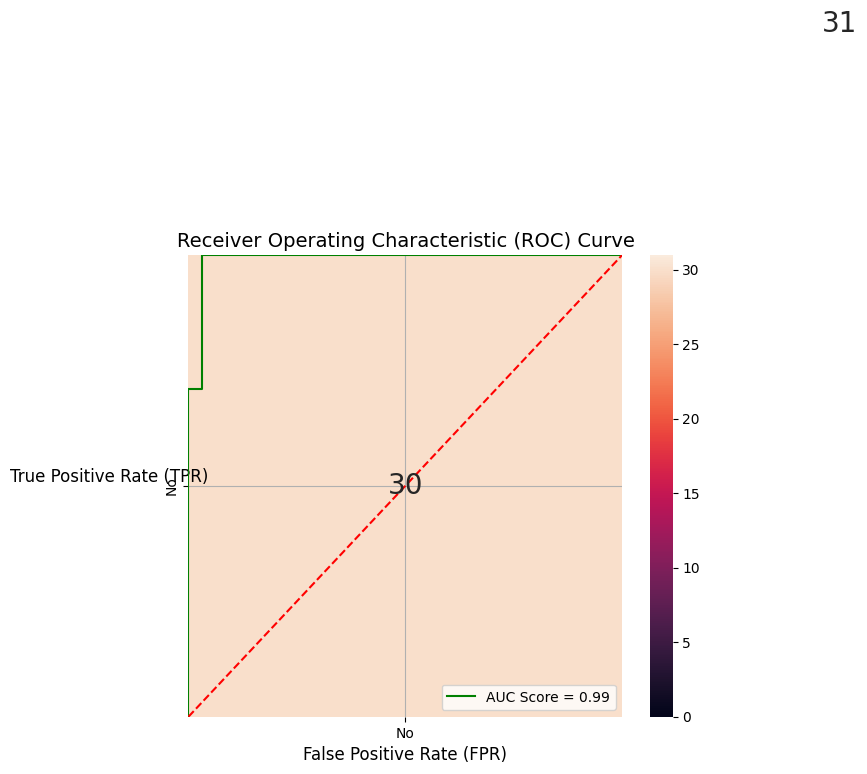


 Classification Report:

              precision    recall  f1-score   support

       bites       1.00      0.97      0.98        31
    no_bites       0.97      1.00      0.98        31

    accuracy                           0.98        62
   macro avg       0.98      0.98      0.98        62
weighted avg       0.98      0.98      0.98        62



In [53]:
dino_model.load_state_dict(torch.load(dino_save_path, map_location=dino_device))
dino_model.eval()

dino_probs, dino_true = [], []
with torch.no_grad():
    for X, y in dino_val_loader:
        probs = torch.sigmoid(dino_model(X.to(dino_device)).view(-1)).cpu().numpy()
        dino_probs.extend(probs.tolist())
        dino_true.extend(y.numpy().tolist())

dino_probs = np.array(dino_probs)
dino_true  = np.array(dino_true)

plot_confusion_matrix(dino_probs, dino_true)
plot_roc_curve(dino_probs, dino_true)
print('=' * 55)
print('\n Classification Report:\n')
print(classification_report(dino_true, (dino_probs > 0.5).astype(int),
                             target_names=['bites', 'no_bites']))
print('=' * 55)

# **Model Comparison — All Binary Classifiers**


── EfficientNetV2S ──
              precision    recall  f1-score   support

       bites       0.83      0.97      0.90        31
    no_bites       0.96      0.81      0.88        31

    accuracy                           0.89        62
   macro avg       0.90      0.89      0.89        62
weighted avg       0.90      0.89      0.89        62


── ConvNeXt-Tiny ──
              precision    recall  f1-score   support

       bites       0.90      0.90      0.90        31
    no_bites       0.90      0.90      0.90        31

    accuracy                           0.90        62
   macro avg       0.90      0.90      0.90        62
weighted avg       0.90      0.90      0.90        62


── EfficientNet-B0 ──
              precision    recall  f1-score   support

       bites       0.96      0.84      0.90        31
    no_bites       0.86      0.97      0.91        31

    accuracy                           0.90        62
   macro avg       0.91      0.90      0.90        62
weighte

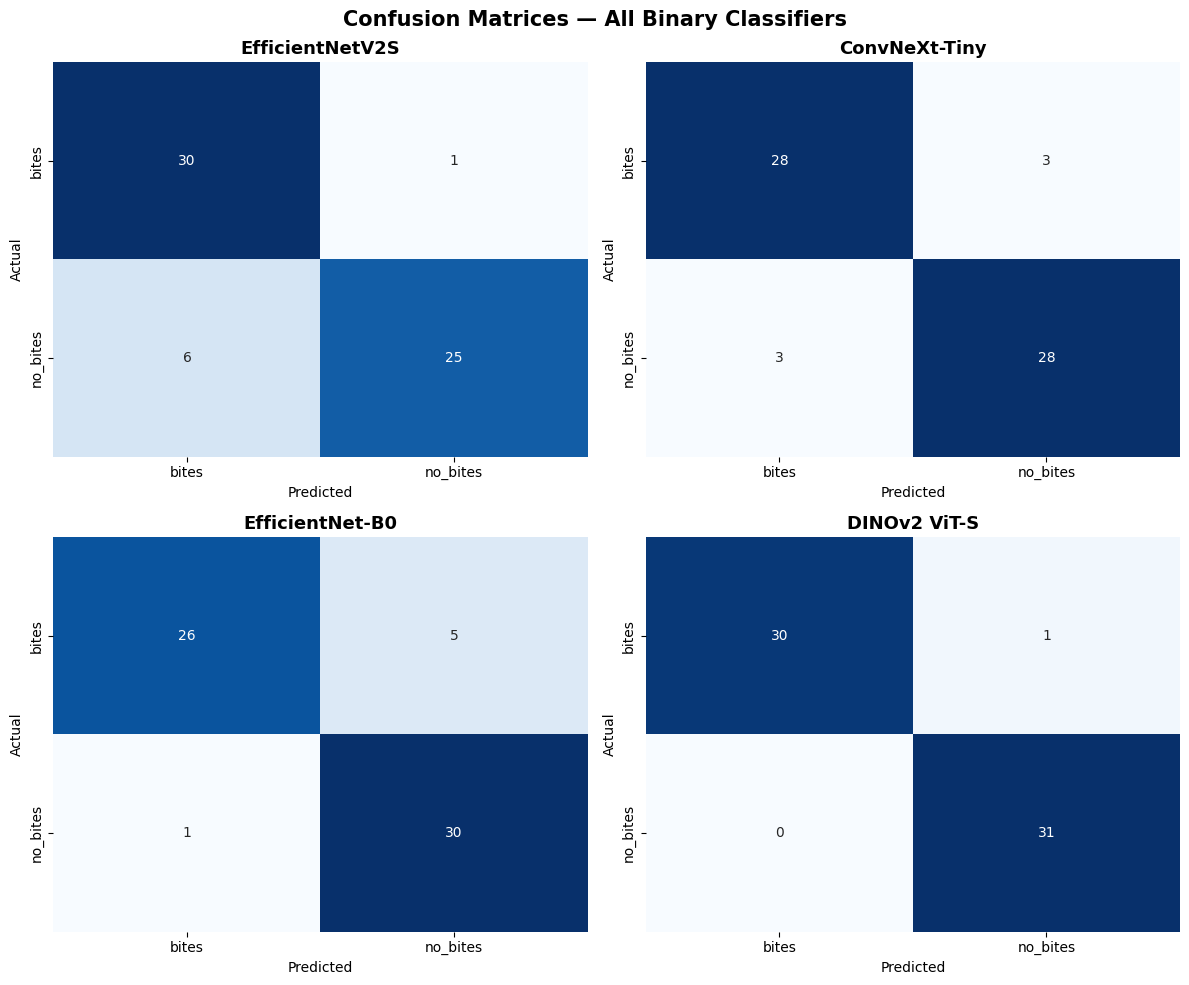

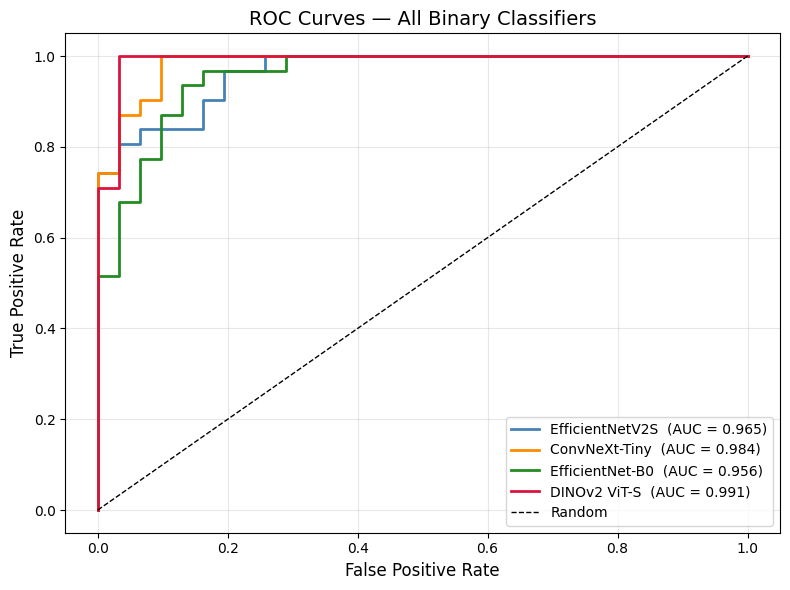

In [54]:
_all_models = [
    ('EfficientNetV2S', eff_prediction.ravel(),    actual_class),
    ('ConvNeXt-Tiny',   cnx_prediction.ravel(),    actual_class),
    ('EfficientNet-B0', eff_b0_prediction.ravel(), actual_class_b0),
    ('DINOv2 ViT-S',    dino_probs,                dino_true),
]

# ── Classification reports ────────────────────────────────────────────────
print('=' * 70)
for name, probs, y_true in _all_models:
    y_pred = (probs > 0.5).astype(int)
    print(f'\n── {name} ──')
    print(classification_report(y_true, y_pred, target_names=['bites', 'no_bites']))
print('=' * 70)

# ── 2×2 confusion matrix grid ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, probs, y_true) in zip(axes.flat, _all_models):
    y_pred = (probs > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=['bites', 'no_bites'],
                yticklabels=['bites', 'no_bites'],
                cmap='Blues', cbar=False)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — All Binary Classifiers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Overlaid ROC curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
for (name, probs, y_true), color in zip(_all_models, colors):
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Binary Classifiers', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()